<div align="center", style="padding-top: 40px; padding-bottom: 40px;">

# <span style="font-family:'Playfair Display', Georgia, serif; font-weight:500; font-size:2.5em;">Comparison of Deep Learning Models for Arrhythmia Heartbeat Detection</span>
### <span style="font-family:'Playfair Display', Georgia, serif; font-weight:250; font-size:1.3em;">Benchmarking Architectures on the MIT-BIH Arrhythmia Database</span>
</div>


<div style="padding-top: 10px; padding-bottom: 10px;">

---
### <span style="font-family:'Playfair Display', Georgia, serif; font-weight:200; font-size:1.5em;"> Phase A - Setup and Prepreparation
---
<span style="font-family:'Playfair Display', Georgia, serif; font-weight:200; font-size:1.2em;">
    
* Fixing random seeds
* importing the libraries used throughout 
* printing a reproducibility record (library versions + hardware)
</span>
</div>

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import sklearn as skl
import imblearn

import wfdb
import shap

SEED = 88

# Set global seeds
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#if running on GPUs (not in google colab)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except (AttributeError, RuntimeError):
    pass

print("\n--- REPRODUCIBILITY RECORD ---")
print(f"Python version:          {sys.version.split()[0]}")
print(f"NumPy version:           {np.__version__}")
print(f"Pandas version:          {pd.__version__}")
print(f"PyTorch version:         {torch.__version__}")
print(f"Scikit-Learn version:    {skl.__version__}")
print(f"Imblearn version:        {imblearn.__version__}")
print(f"WFDB version:            {wfdb.__version__}")
print(f"SHAP version:            {shap.__version__}")
print(f"CUDA Available:          {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device:          {torch.cuda.get_device_name(0)}")
print("------------------------------")


--- REPRODUCIBILITY RECORD ---
Python version:          3.12.10
NumPy version:           1.26.4
Pandas version:          2.2.2
PyTorch version:         2.3.0+cpu
Scikit-Learn version:    1.4.2
Imblearn version:        0.12.2
WFDB version:            4.1.2
SHAP version:            0.45.1
CUDA Available:          False
------------------------------


<div style="padding-top: 10px; padding-bottom: 10px;">

---
### <span  style="font-family:'Playfair Display', Georgia, serif; font-weight:200; font-size:1.5em;">Phase B - Data Loading and Exploratory Visualization
---
<span style="font-family:'Playfair Display', Georgia, serif; font-weight:200; font-size:1.2em;">

Loads a single MIT-BIH record (**100**) via `wfdb.rdrecord()` / `wfdb.rdann()` from Local secondry memory
* Printing inital 5 records of the dataset
* Visualizations used here:
    1. **Raw waveform**
    2. **Annotated waveform**
    3. **Dual-lead comparison (MLII and V5)**
    4. **RR-interval scatter plot**
    5. **Bar Graphs for Class Distribution of record name '100'**
    6. **Heatmap for Class Distribution of All records in dataset**
</span>
</div>

In [2]:
import pandas as pd
from IPython.display import display, HTML


record = wfdb.rdrecord('./dataset/100')
annotation = wfdb.rdann('./dataset/100', 'atr')

df = pd.DataFrame(record.p_signal[:5], columns=record.sig_name)
dfa = pd.DataFrame({'sample': annotation.sample, 'symbol': annotation.symbol})
html_str = f"""
<div style="display: flex; gap: 70px;">
    <div>
        {df.head().to_html()}
    </div>
    <div>
        {dfa.head().to_html()}
    </div>
</div>
"""

# Render the side-by-side HTML
display(HTML(html_str))

,MLII,V5
0,-0.145,-0.065
1,-0.145,-0.065
2,-0.145,-0.065
3,-0.145,-0.065
4,-0.145,-0.065
,sample,symbol
0,18,+
1,77,N
2,370,N
3,662,N


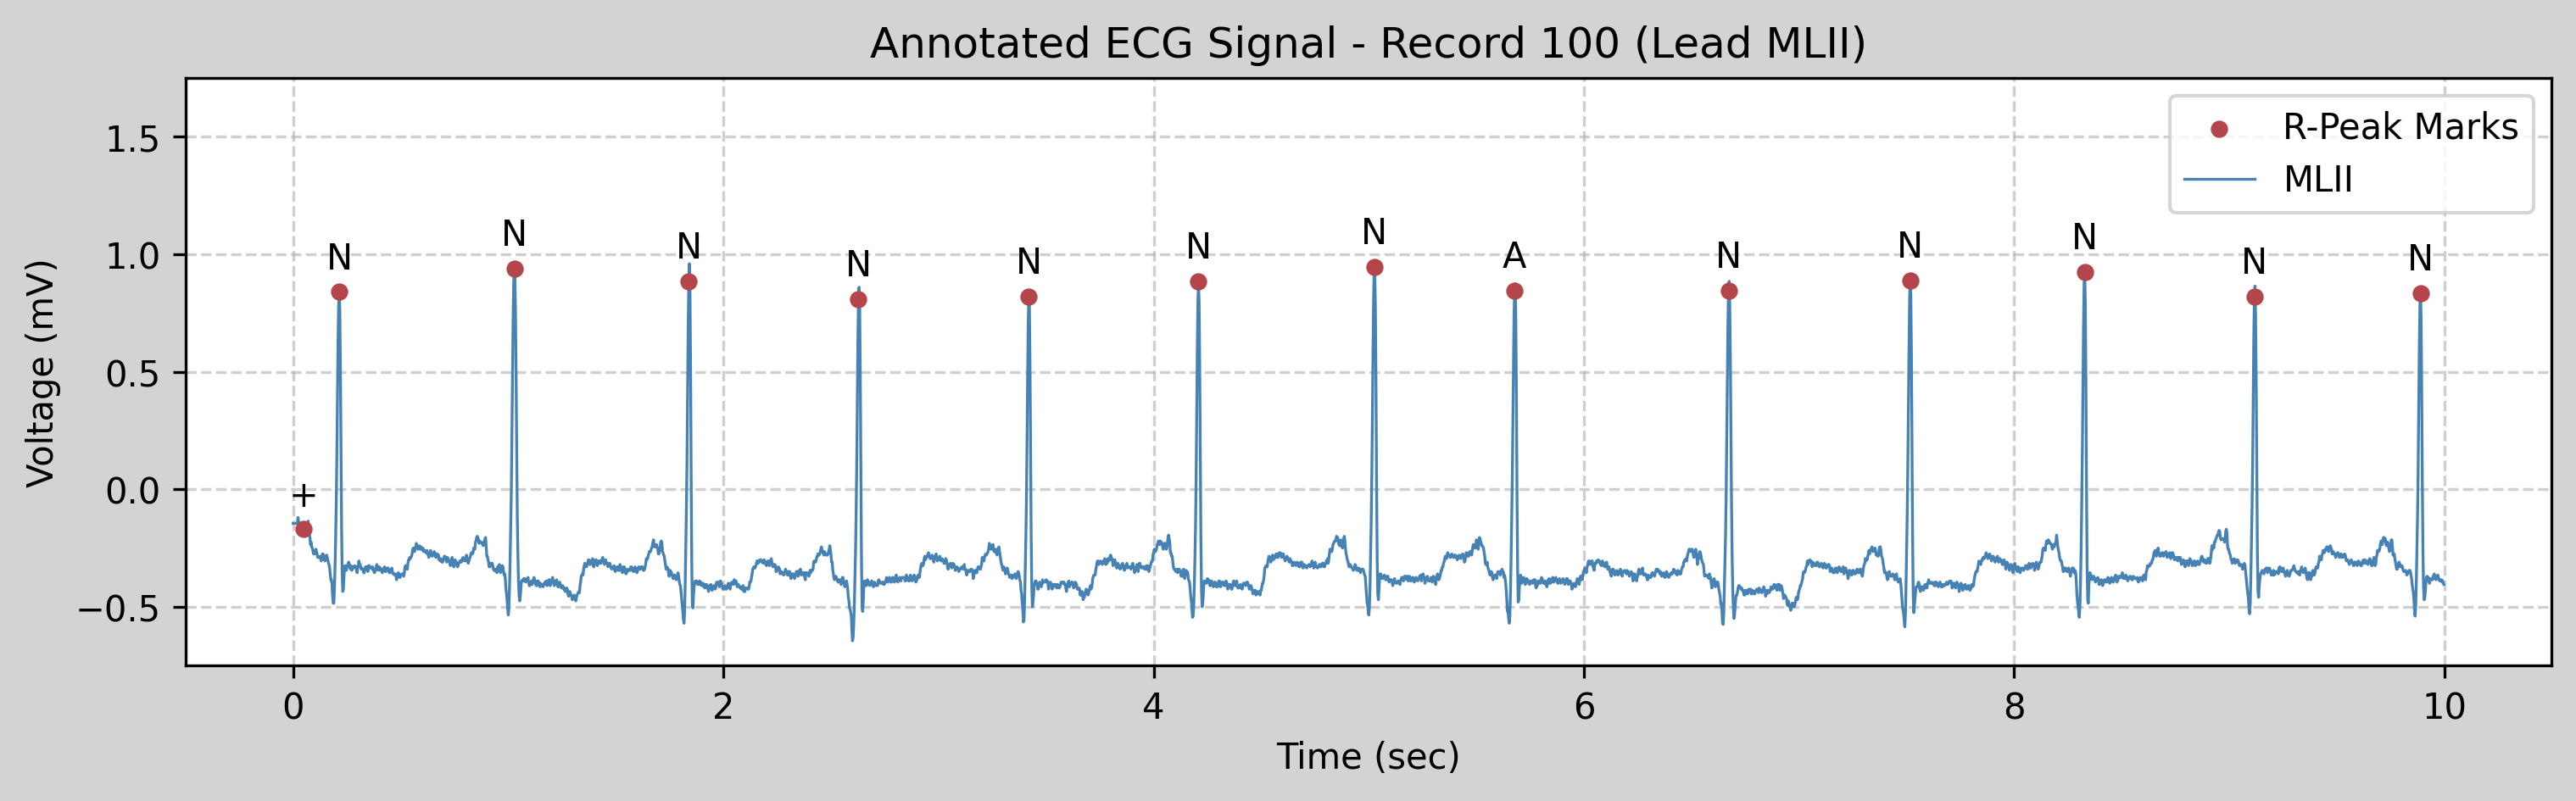

In [3]:
fs=record.fs
num_samples=fs*10

time_axis = np.arange(num_samples) / fs
signal_ch0 = record.p_signal[:num_samples, 0]

mask = annotation.sample < num_samples
peak_samples = annotation.sample[mask]
peak_symbols = np.array(annotation.symbol) [mask]

# Convert peak sample indices to time & voltage values
peak_times = peak_samples / fs
peak_voltages = record.p_signal[peak_samples, 0]

plt.figure(dpi=300, figsize=(12, 3),facecolor='lightgrey')
# Overlay Scatter Plot for Annotations
plt.scatter(peak_times, peak_voltages, color="#B4464B", s=15, zorder=5, label='R-Peak Marks')
# Annotate each scatter point with its Cardiologist Symbol ('N', etc.)
for t, v, symbol in zip(peak_times, peak_voltages, peak_symbols):
    plt.text(t, v + 0.1, symbol, fontsize=10, ha='center')
plt.plot(time_axis, signal_ch0,color='steelblue' ,linewidth=0.8, label=record.sig_name[0])
plt.title(f"Annotated ECG Signal - Record {record.record_name} (Lead {record.sig_name[0]})")
plt.xlabel("Time (sec)")
plt.ylabel("Voltage (mV)")
plt.grid(linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.ylim(-0.75, 1.75)
plt.show()

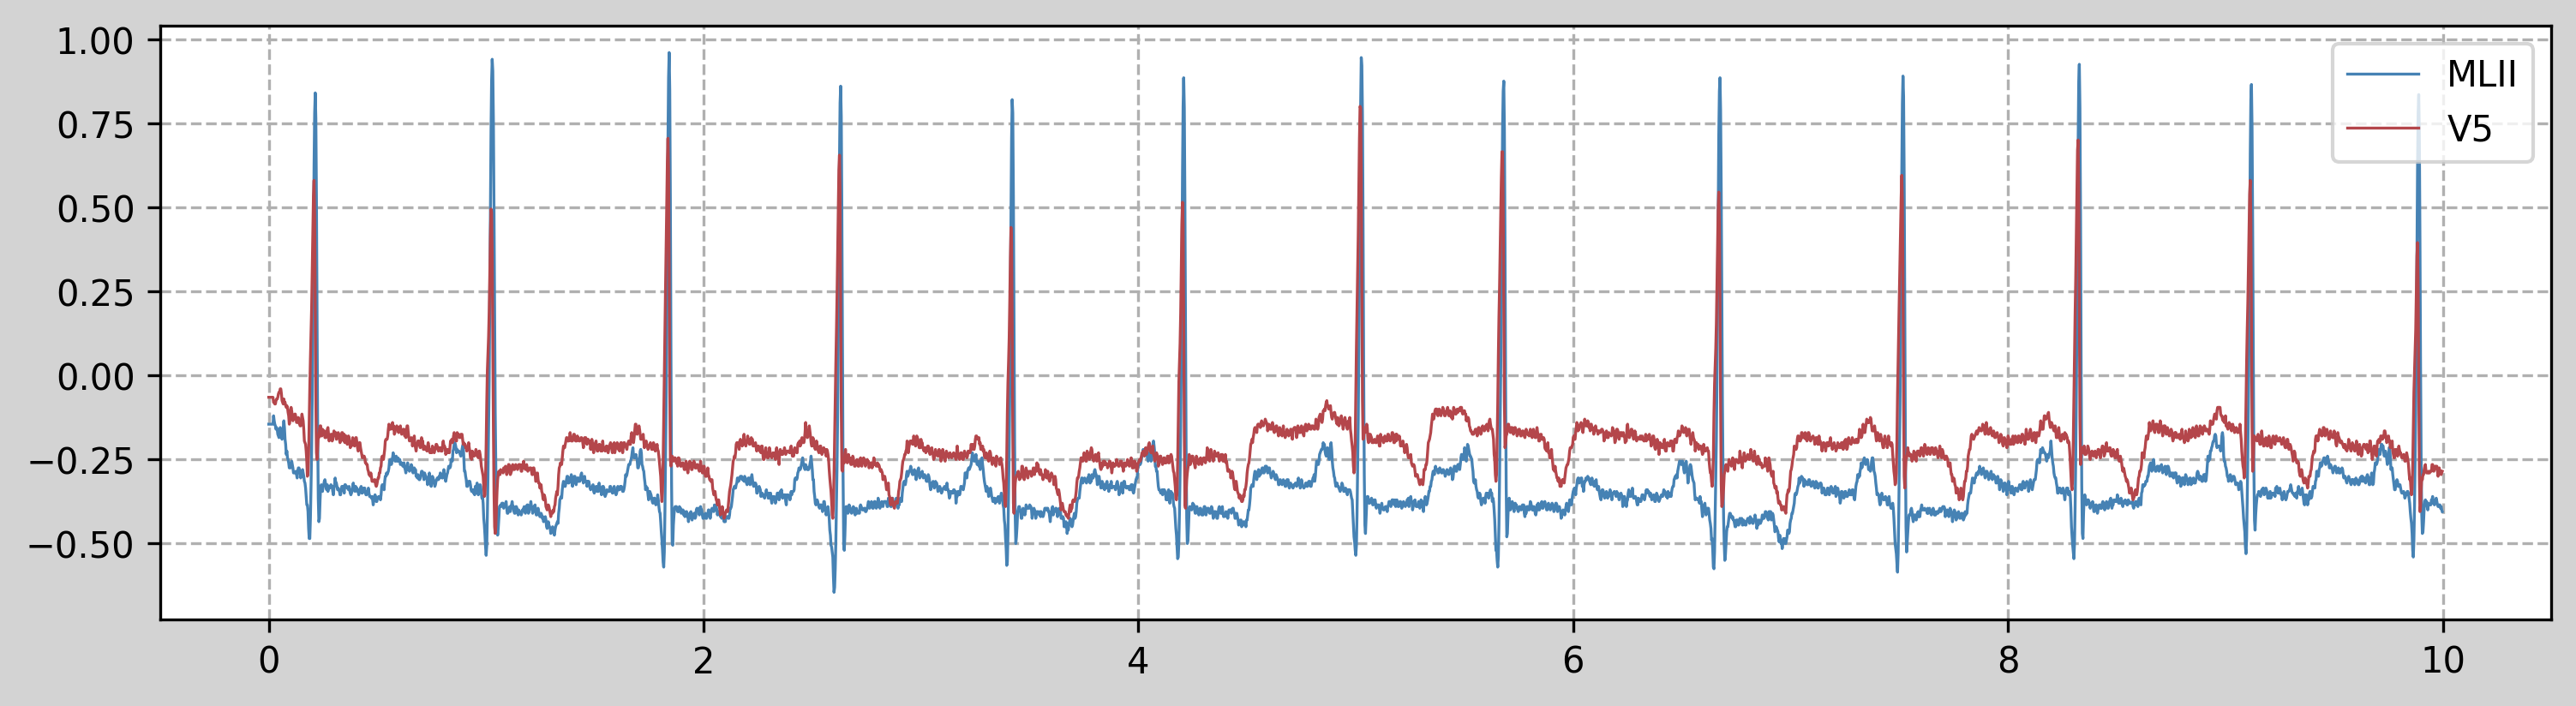

In [4]:
plt.figure(dpi=300, figsize=(12, 3),facecolor='lightgrey')
plt.plot(time_axis, record.p_signal[:num_samples, 0],color='steelblue',linewidth=0.8, label=record.sig_name[0])
plt.plot(time_axis, record.p_signal[:num_samples, 1],color='#B4464B', linewidth=0.8, label=record.sig_name[1])
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

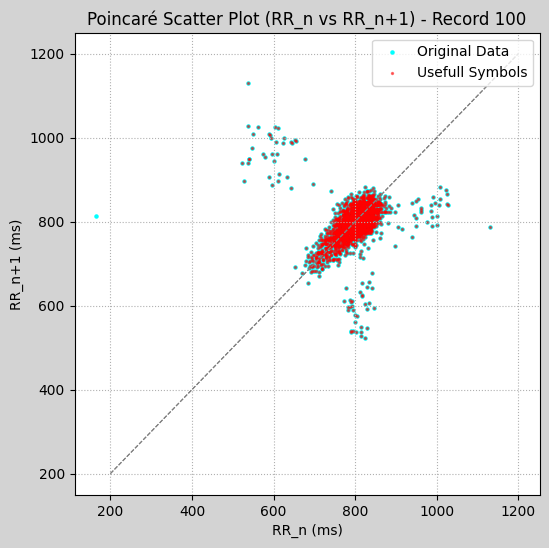

In [5]:
# Compute RR-intervals (differences between consecutive peak samples in milliseconds)
rr_intervals = np.diff(annotation.sample) / fs * 1000  # in ms
rr_n = rr_intervals[:-1]    # RR_n
rr_n_plus_1 = rr_intervals[1:] # RR_{n+1}

plt.figure(dpi=100, figsize=(6, 6), facecolor='lightgrey')
plt.scatter(rr_n, rr_n_plus_1, color='cyan', alpha=1, s=5, label="Original Data")
plt.plot([200, 1200], [200, 1200], color='gray', linestyle='--', linewidth=0.8)  # Identity line x=y

#Seperating Non-beat symbols that deviates the scatter plot
BeatSymbol={'N','L','R','A','a','J','S','V','F','e','j','E','/','f','Q'}
mask=np.isin(annotation.symbol, list(BeatSymbol))
BeatSample=annotation.sample[mask]
BeatSymbol=np.array(annotation.symbol)[mask]

rr_intervals = np.diff(BeatSample) / fs * 1000  # in ms
rr_n = rr_intervals[:-1]    # RR_n
rr_n_plus_1 = rr_intervals[1:] # RR_{n+1}

plt.scatter(rr_n, rr_n_plus_1, color='red', alpha=0.5, s=2, label="Usefull Symbols")
plt.plot([200, 1200], [200, 1200], color='gray', linestyle='--', linewidth=0.8)  # Identity line x=y
plt.title(f"Poincaré Scatter Plot (RR_n vs RR_n+1) - Record {record.record_name}")
plt.xlabel("RR_n (ms)")
plt.ylabel("RR_n+1 (ms)")
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')
plt.show()

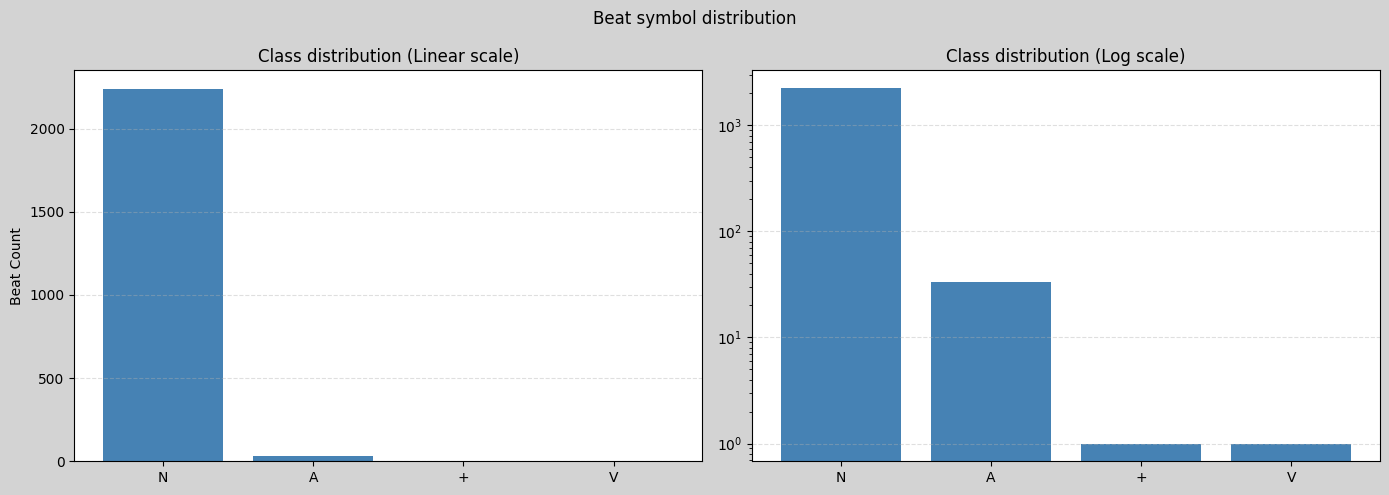

In [6]:
# Class Distribution using bar graphs in linear and log scales
SymbolCounts=pd.Series(annotation.symbol).value_counts()
fig, axes=plt.subplots(1,2,figsize=(14,5), facecolor='lightgrey')
axes[0].bar(SymbolCounts.index, SymbolCounts.values, color='steelblue')
axes[0].set_title("Class distribution (Linear scale)")
axes[0].set_ylabel("Beat Count")
axes[0].grid(axis='y',  alpha = 0.4, linestyle='--')

axes[1].bar(SymbolCounts.index, SymbolCounts.values, color='steelblue')
axes[1].set_yscale("log")
axes[1].set_title("Class distribution (Log scale)")
axes[1].grid(axis='y', alpha = 0.4, linestyle='--')

fig.suptitle("Beat symbol distribution")
fig.tight_layout()
plt.show()

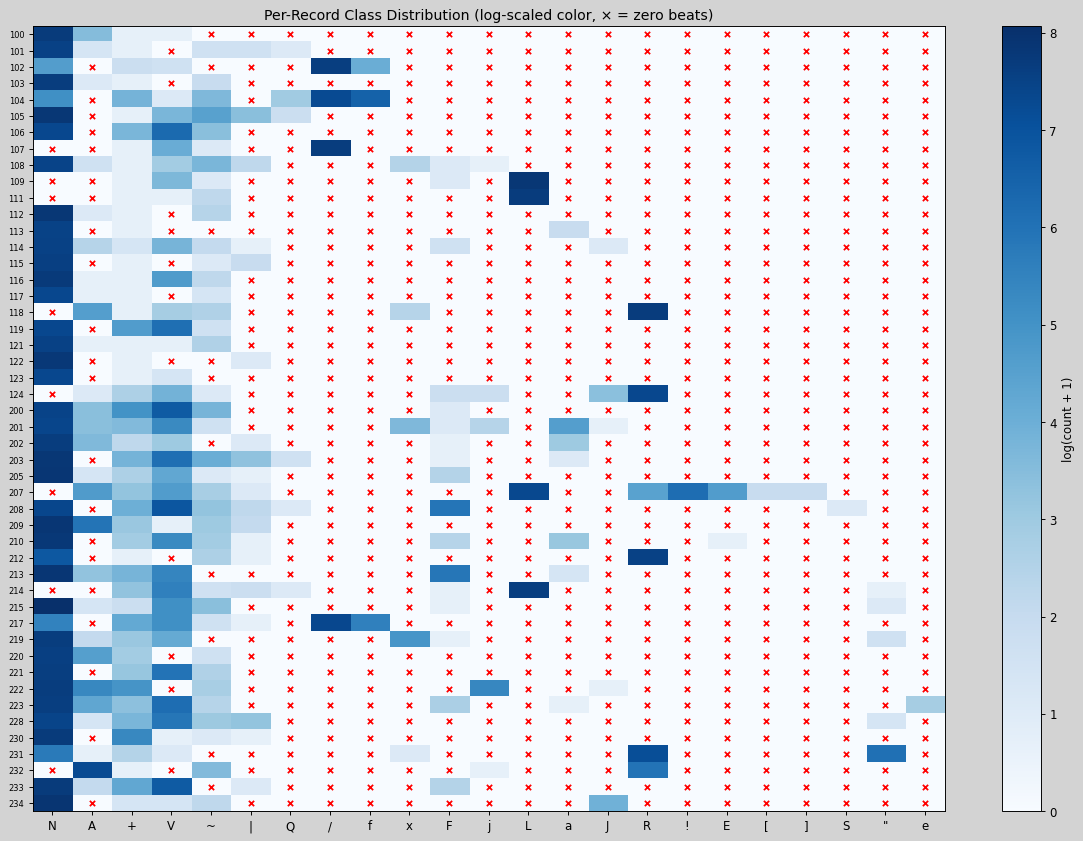

In [7]:
#Pre-Record Class Distribution Heatmap for all the records in MIT-BIH dataset
import glob


record_names = sorted(set(os.path.splitext(os.path.basename(f))[0] for f in glob.glob('./dataset/*.hea')))
rows = []
for rec_name in record_names:
    ann = wfdb.rdann(f'./dataset/{rec_name}', 'atr')
    rows.append(pd.Series(ann.symbol).value_counts().rename(rec_name))

class_matrix = pd.DataFrame(rows).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 10), facecolor='lightgrey', dpi=85)
im = ax.imshow(np.log1p(class_matrix.values), aspect='auto', cmap='Blues')

ax.set_xticks(range(len(class_matrix.columns)))
ax.set_xticklabels(class_matrix.columns)
ax.set_yticks(range(len(class_matrix.index)))
ax.set_yticklabels(class_matrix.index, fontsize=7)

# flag zero cells explicitly — this is the part that matters for GroupKFold safety
zero_rows, zero_cols = np.where(class_matrix.values == 0)
ax.scatter(zero_cols, zero_rows, marker='x', color='red', s=20)

ax.set_title("Per-Record Class Distribution (log-scaled color, × = zero beats)")
fig.colorbar(im, ax=ax, label="log(count + 1)")
fig.tight_layout()
plt.show()

<div  style="padding-top: 10px; padding-bottom: 10px;">
    
---
### <span style="font-family:'Playfair Display', Georgia, serif; font-weight:200; font-size:1.5em;"> Phase C - Data preprocessing and dataset spliting </span>
---
<span style="font-family:'Playfair Display', Georgia, serif; font-weight:100; font-size:1.3em;">
Data Spliting into K Folds for fault tolerence and cross validation

</span>
</div>